<a href="https://colab.research.google.com/github/KaRaMbIIt/Car_Sales_Mineria/blob/main/EV2_Mineria_Datos_Thomas_Felipei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV2 - Minería de Datos

## Predicción de precios de vehículos usando Machine Learning

**Integrantes:**  
- Thomas Leighton  
- Felipe Tapia  

**Asignatura:** Minería de Datos  
**Sección:** 004-D  

**Dataset:** `car_prices.csv`  
**Variable objetivo:** `sellingprice`  
**Moneda:** Dólares estadounidenses (USD)  
**Modelos utilizados:**  
- Regresión Lineal Múltiple  
- Random Forest Regressor  

---

## Contexto de nuestra presentación

Nosotros presentaremos este trabajo directamente desde este cuaderno de Google Colab.  
Por eso, el notebook está organizado como si fuera nuestra presentación: primero explicaremos el problema, luego mostraremos cómo preparamos los datos, después aplicaremos los modelos y finalmente interpretaremos los resultados obtenidos.

Nuestro objetivo principal será **predecir el precio de venta de vehículos usados** a partir de distintas características del auto, como el año, condición, millaje, marca, carrocería, transmisión y valor estimado de mercado.

Como el precio de venta es un valor numérico, este corresponde a un problema de **regresión**. Por ese motivo usaremos dos modelos de regresión:

1. **Regresión Lineal Múltiple**, como modelo base, simple e interpretable.
2. **Random Forest Regressor**, como modelo más avanzado, capaz de capturar relaciones más complejas.

Antes de entrenar los modelos, también mostraremos una **matriz de correlación de Pearson** para entender qué variables numéricas se relacionan más con el precio de venta.

## 1. Objetivo del análisis

En esta presentación, nosotros construiremos y compararemos dos modelos de Machine Learning para predecir el precio de venta de un vehículo usado.

La variable que queremos predecir es:

- **`sellingprice`**: precio final de venta del vehículo.

Esta variable está expresada en **dólares estadounidenses (USD)**, ya que el dataset corresponde a ventas de vehículos en Estados Unidos.

Para cumplir el objetivo utilizaremos dos modelos:

1. **Regresión Lineal Múltiple:** nos servirá como modelo base. Es más fácil de interpretar y permite explicar cómo distintas variables influyen en el precio.
2. **Random Forest Regressor:** nos servirá como modelo más potente, porque combina varios árboles de decisión y puede detectar relaciones más complejas.

Además, antes de entrenar los modelos, nosotros realizaremos una **matriz de correlación de Pearson** para revisar la relación entre las variables numéricas y el precio de venta.

## 2. Carga de librerías

Para comenzar, nosotros importaremos las librerías necesarias para trabajar en el análisis.

- `pandas` y `numpy`: nos permiten trabajar con datos.
- `matplotlib` y `seaborn`: nos permiten crear gráficos.
- `sklearn`: contiene las herramientas de Machine Learning, como modelos, métricas y transformación de variables.

Estas librerías son las que usaremos durante todo el notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

## 3. Carga del dataset

Ahora cargamos el archivo `car_prices.csv`, que contiene la información de ventas de vehículos usados.

Para ejecutar este notebook en Google Colab, el archivo tiene que estar subido al entorno con el mismo nombre:

```text
car_prices.csv
```

Si el archivo se encuentra en otra ruta, se cambia el valor de la variable `ruta_archivo`.


In [4]:
ruta_archivo = '/content/sample_data/car_prices.csv'

df = pd.read_csv(ruta_archivo)

print("Cantidad de filas y columnas del dataset:")
print(df.shape)

print("\nPrimeras filas del dataset:")
display(df.head())

Cantidad de filas y columnas del dataset:
(558837, 16)

Primeras filas del dataset:


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## 4. Exploración inicial del dataset

Antes de aplicar cualquier modelo, nosotros necesitamos conocer los datos.

En esta sección revisaremos:

- Los nombres de las columnas.
- El tipo de dato de cada columna.
- La cantidad de valores nulos.
- Una descripción estadística de las variables numéricas.

Esto es importante porque un modelo de Machine Learning necesita datos limpios y bien preparados para entregar resultados confiables.

In [5]:
print("Columnas del dataset:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes)

print("\nCantidad de valores nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nEstadísticas descriptivas de variables numéricas:")
display(df.describe().T)

Columnas del dataset:
['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']

Tipos de datos:


,0
year,int64
make,object
model,object
trim,object
body,object
transmission,object
vin,object
state,object
condition,float64
odometer,float64



Cantidad de valores nulos por columna:


,0
transmission,65352
body,13195
condition,11820
trim,10651
model,10399
make,10301
color,749
interior,749
odometer,94
mmr,38



Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
year,558837.0,2010.038927,3.966864,1982.0,2007.0,2012.0,2013.0,2015.0
condition,547017.0,30.672365,13.402832,1.0,23.0,35.0,42.0,49.0
odometer,558743.0,68320.017767,53398.542821,1.0,28371.0,52254.0,99109.0,999999.0
mmr,558799.0,13769.377495,9679.967174,25.0,7100.0,12250.0,18300.0,182000.0
sellingprice,558825.0,13611.358810,9749.501628,1.0,6900.0,12100.0,18200.0,230000.0


## 5. Explicación de las variables principales

El dataset contiene información de vehículos vendidos. Algunas columnas son numéricas y otras son categóricas.

Para nuestro trabajo, las variables más importantes serán:

| Variable | Tipo | Explicación |
|---|---|---|
| `year` | Numérica | Año del vehículo |
| `condition` | Numérica | Condición o estado del vehículo |
| `odometer` | Numérica | Millaje/kilometraje recorrido por el vehículo |
| `mmr` | Numérica | Valor estimado de mercado del vehículo |
| `make` | Categórica | Marca del vehículo |
| `body` | Categórica | Tipo de carrocería |
| `transmission` | Categórica | Tipo de transmisión |
| `sellingprice` | Numérica | Precio final de venta del vehículo en USD |

Nosotros usaremos `sellingprice` como variable objetivo, porque es el valor que queremos predecir.

## 6. Limpieza y selección inicial de columnas

No todas las columnas del dataset son convenientes para este primer modelo.

Por ejemplo:

- `vin` es un identificador único del vehículo, por lo tanto no ayuda a encontrar un patrón general.
- `seller` tiene demasiados nombres distintos de vendedores.
- `model` y `trim` tienen muchas categorías distintas, lo que puede hacer más pesado el modelo.
- `saledate` es una fecha en formato texto y requiere una transformación adicional.

Para esta presentación, nosotros usaremos columnas más simples y defendibles dentro del límite de 13 minutos. La idea no es usar todas las variables, sino elegir variables que tengan sentido para explicar el precio.

In [6]:
columnas_modelo = [
    'year',
    'condition',
    'odometer',
    'mmr',
    'make',
    'body',
    'transmission',
    'sellingprice'
]

df_modelo = df[columnas_modelo].copy()

print("Columnas seleccionadas para el análisis:")
print(df_modelo.columns.tolist())

print("\nValores nulos en las columnas seleccionadas:")
display(df_modelo.isnull().sum())

Columnas seleccionadas para el análisis:
['year', 'condition', 'odometer', 'mmr', 'make', 'body', 'transmission', 'sellingprice']

Valores nulos en las columnas seleccionadas:


,0
year,0
condition,11820
odometer,94
mmr,38
make,10301
body,13195
transmission,65352
sellingprice,12


## 7. Tratamiento de valores nulos

Los modelos de Machine Learning no trabajan correctamente si existen valores vacíos en las columnas que vamos a usar.

Por eso, nosotros eliminaremos los registros que tengan valores nulos en las columnas seleccionadas.

Esta decisión es adecuada para este trabajo porque el dataset tiene una gran cantidad de registros. Aunque eliminemos algunas filas incompletas, todavía quedará suficiente información para entrenar y evaluar los modelos.

In [7]:
filas_antes = df_modelo.shape[0]

df_modelo = df_modelo.dropna()

filas_despues = df_modelo.shape[0]

print("Filas antes de eliminar nulos:", filas_antes)
print("Filas después de eliminar nulos:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues)

print("\nValores nulos restantes:")
display(df_modelo.isnull().sum())

Filas antes de eliminar nulos: 558837
Filas después de eliminar nulos: 472961
Filas eliminadas: 85876

Valores nulos restantes:


,0
year,0
condition,0
odometer,0
mmr,0
make,0
body,0
transmission,0
sellingprice,0


## 8. Revisión de valores extremos o poco coherentes

Antes de entrenar los modelos, nosotros revisaremos valores que podrían afectar el resultado.

Por ejemplo:

- Precios de venta iguales o menores a 0.
- Millajes negativos.
- Valores de mercado (`mmr`) iguales o menores a 0.
- Años fuera de un rango razonable.

No eliminamos datos por eliminar. Lo hacemos para evitar que registros claramente incorrectos afecten el aprendizaje de los modelos.

In [8]:
filas_antes = len(df_modelo)

df_modelo = df_modelo[
    (df_modelo['sellingprice'] > 0) &
    (df_modelo['mmr'] > 0) &
    (df_modelo['odometer'] > 0) &
    (df_modelo['year'] >= 1980) &
    (df_modelo['year'] <= 2026)
].copy()

filas_despues = len(df_modelo)
filas_eliminadas = filas_antes - filas_despues

print("Verificación de rangos:")
print(f"Filas revisadas: {filas_antes:,}")
print(f"Filas conservadas: {filas_despues:,}")
print(f"Filas eliminadas por valores fuera de rango: {filas_eliminadas:,}")

print("\nInterpretación:")
if filas_eliminadas == 0:
    print("En esta revisión no se eliminaron registros, porque los datos ya cumplían los rangos definidos.")
    print("Esto indica que, después de la limpieza previa, las columnas principales ya tenían valores coherentes para el modelo.")
else:
    print("En esta revisión se eliminaron registros con valores poco coherentes, como precios, MMR u odómetros iguales o menores a cero.")
    print("Esto ayuda a evitar que datos incorrectos afecten el entrenamiento de los modelos.")

Verificación de rangos:
Filas revisadas: 472,961
Filas conservadas: 472,961
Filas eliminadas por valores fuera de rango: 0

Interpretación:
En esta revisión no se eliminaron registros, porque los datos ya cumplían los rangos definidos.
Esto indica que, después de la limpieza previa, las columnas principales ya tenían valores coherentes para el modelo.


## 9. Ajuste para trabajar mejor en Colab

El dataset original es bastante grande. Para que el entrenamiento sea más rápido durante la presentación en clases, nosotros trabajaremos con una muestra aleatoria.

Esto no cambia el objetivo del trabajo. Solo permite que el notebook sea más liviano y se ejecute mejor en Google Colab.

La muestra mantiene registros reales del dataset original, por lo tanto seguimos trabajando con datos válidos.

In [9]:
# Si el equipo o Colab es lento, se puede bajar este número a 30000.
# Si se quiere usar más información, se puede subir a 100000.
tamano_muestra = 50000

if len(df_modelo) > tamano_muestra:
    df_modelo = df_modelo.sample(n=tamano_muestra, random_state=42)

print("Tamaño de datos usado para modelar:")
print(df_modelo.shape)

Tamaño de datos usado para modelar:
(50000, 8)


## 10. Matriz de correlación de Pearson

En esta parte presentamos la matriz de correlación de Pearson para revisar la relación inicial entre las variables numéricas y el precio de venta (`sellingprice`).

Nosotros decidimos mostrar primero Pearson con las variables numéricas originales porque es la forma más clara para explicar el análisis en una presentación. Las variables revisadas son `year`, `condition`, `odometer`, `mmr` y `sellingprice`.

Esta decisión es importante: también sería posible aplicar One-Hot Encoder antes de Pearson, porque las categorías quedarían transformadas en columnas de 0 y 1. Sin embargo, para este dataset eso generaría muchas columnas y una matriz demasiado grande, especialmente por variables como `make`, `body` y `transmission`.

Por eso, usamos Pearson como análisis exploratorio inicial y después aplicamos One-Hot Encoder para preparar los datos que entrarán a los modelos.


Matriz de correlación de Pearson:


,year,condition,odometer,mmr,sellingprice
year,1.000000,0.332043,-0.775882,0.590152,0.580504
condition,0.332043,1.000000,-0.312651,0.278489,0.319378
odometer,-0.775882,-0.312651,1.000000,-0.584001,-0.578246
mmr,0.590152,0.278489,-0.584001,1.000000,0.983440
sellingprice,0.580504,0.319378,-0.578246,0.983440,1.000000


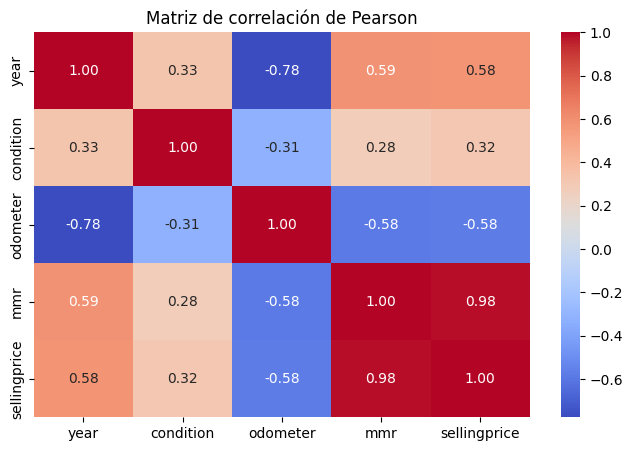


Interpretación de la matriz de Pearson:


,Correlación con sellingprice
mmr,0.983440
year,0.580504
odometer,-0.578246
condition,0.319378


- mmr: tiene una relación positiva con el precio (0.983). Cuando esta variable aumenta, el precio tiende a aumentar.
- year: tiene una relación positiva con el precio (0.581). Cuando esta variable aumenta, el precio tiende a aumentar.
- odometer: tiene una relación negativa con el precio (-0.578). Cuando esta variable aumenta, el precio tiende a disminuir.
- condition: tiene una relación positiva con el precio (0.319). Cuando esta variable aumenta, el precio tiende a aumentar.

Conclusión de esta sección:
La matriz de Pearson nos ayuda a identificar qué variables numéricas se relacionan más con el precio antes de entrenar los modelos.
Si mmr aparece como la correlación más alta, significa que el valor estimado de mercado es la variable numérica más cercana al precio final de venta.
Odometer normalmente debería tener relación negativa, porque un vehículo con mayor millaje suele venderse a menor precio.


In [10]:
columnas_numericas = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']

correlacion = df_modelo[columnas_numericas].corr(method='pearson')

print("Matriz de correlación de Pearson:")
display(correlacion)

plt.figure(figsize=(8, 5))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación de Pearson')
plt.show()

# Interpretación directa para la presentación
correlaciones_precio = correlacion['sellingprice'].drop('sellingprice').sort_values(key=abs, ascending=False)

print("\nInterpretación de la matriz de Pearson:")
display(correlaciones_precio.to_frame(name='Correlación con sellingprice'))

for variable, valor in correlaciones_precio.items():
    if valor > 0:
        print(f"- {variable}: tiene una relación positiva con el precio ({valor:.3f}). Cuando esta variable aumenta, el precio tiende a aumentar.")
    elif valor < 0:
        print(f"- {variable}: tiene una relación negativa con el precio ({valor:.3f}). Cuando esta variable aumenta, el precio tiende a disminuir.")
    else:
        print(f"- {variable}: no muestra una relación lineal clara con el precio ({valor:.3f}).")

print("\nConclusión de esta sección:")
print("La matriz de Pearson nos ayuda a identificar qué variables numéricas se relacionan más con el precio antes de entrenar los modelos.")
print("Si mmr aparece como la correlación más alta, significa que el valor estimado de mercado es la variable numérica más cercana al precio final de venta.")
print("Odometer normalmente debería tener relación negativa, porque un vehículo con mayor millaje suele venderse a menor precio.")


## 12. Tipo de Regresión Lineal que elegimos

En regresión lineal existen dos formas principales que debemos diferenciar:

| Tipo de regresión | Explicación simple | Ejemplo |
|---|---|---|
| **Regresión Lineal Simple** | Usa una sola variable para predecir el resultado | Predecir el precio usando solo `odometer` |
| **Regresión Lineal Múltiple** | Usa dos o más variables para predecir el resultado | Predecir el precio usando `year`, `condition`, `odometer`, `mmr`, `make`, `body` y `transmission` |

Nosotros elegimos **Regresión Lineal Múltiple** porque el precio de un vehículo no depende de una sola característica.  
El precio puede cambiar por varios factores al mismo tiempo, como el año, el millaje, el estado del auto, la marca, la transmisión y el valor estimado de mercado.

Por eso, usar una regresión simple sería demasiado limitado para este problema. En cambio, la regresión lineal múltiple nos permite trabajar con varias variables predictoras y representar mejor el comportamiento del precio.

## 13. Separación de variables predictoras y variable objetivo

Ahora nosotros separaremos los datos en dos partes:

- **X:** variables que usaremos para predecir.
- **y:** variable que queremos predecir.

La variable objetivo será `sellingprice`, que corresponde al precio de venta en dólares estadounidenses.

In [11]:
X = df_modelo.drop(columns=['sellingprice'])
y = df_modelo['sellingprice']

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print("sellingprice")

print("\nTamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Variables predictoras:
['year', 'condition', 'odometer', 'mmr', 'make', 'body', 'transmission']

Variable objetivo:
sellingprice

Tamaño de X: (50000, 7)
Tamaño de y: (50000,)


## 14. Variables numéricas y categóricas

Los modelos no pueden trabajar directamente con texto como `make`, `body` o `transmission`.

Por eso, nosotros separaremos las columnas en:

- **Variables numéricas:** se pueden usar directamente.
- **Variables categóricas:** se transformarán con One-Hot Encoder.

Usaremos **One-Hot Encoder** porque convierte categorías en columnas de 0 y 1, sin crear un orden falso entre categorías.

Por ejemplo, no sería correcto decir que una marca vale 1 y otra vale 2, porque eso podría hacer que el modelo piense que una marca es “mayor” que otra. Con One-Hot Encoder evitamos ese problema.

In [12]:
variables_numericas = ['year', 'condition', 'odometer', 'mmr']
variables_categoricas = ['make', 'body', 'transmission']

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['year', 'condition', 'odometer', 'mmr']

Variables categóricas:
['make', 'body', 'transmission']


## 15. División en entrenamiento y prueba

Para evaluar correctamente los modelos, nosotros separaremos los datos en dos partes:

- **Entrenamiento:** datos que el modelo usa para aprender.
- **Prueba:** datos que el modelo no vio durante el entrenamiento y que sirven para evaluar su rendimiento.

Esto permite saber si el modelo aprendió patrones generales o si solo memorizó los datos.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (40000, 7)
Tamaño de X_test: (10000, 7)
Tamaño de y_train: (40000,)
Tamaño de y_test: (10000,)


## 16. Preparación de datos con One-Hot Encoder

Aquí definiremos la transformación de los datos antes de entrenar los modelos.

Para las variables categóricas aplicaremos **One-Hot Encoder**.

Para la **Regresión Lineal Múltiple** también escalaremos las variables numéricas con `StandardScaler`, porque este modelo puede beneficiarse de que las variables estén en una escala más comparable.

En **Random Forest** no es obligatorio escalar, porque los árboles de decisión no dependen de la escala de las variables. Aun así, mantendremos un proceso ordenado usando pipelines separados para cada modelo.

In [14]:
# Preprocesamiento para Regresión Lineal
preprocesamiento_lineal = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
    ]
)

# Preprocesamiento para Random Forest
preprocesamiento_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', variables_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
    ]
)

## 17. Modelo 1: Regresión Lineal Múltiple

El primer modelo que usaremos será **Regresión Lineal Múltiple**.

No usamos regresión lineal simple porque no queremos predecir el precio usando una sola variable. En este caso, el precio de un vehículo puede depender de varias características al mismo tiempo.

Por eso, la regresión lineal múltiple es más adecuada para nuestro problema, ya que permite usar varias variables predictoras, por ejemplo:

- Año del vehículo.
- Condición.
- Millaje.
- Valor estimado de mercado.
- Marca.
- Tipo de carrocería.
- Transmisión.

Este modelo es útil porque:

- Es simple.
- Es fácil de explicar.
- Sirve como modelo base para comparar con Random Forest.

Su principal limitación es que asume una relación principalmente lineal entre las variables y el precio, por lo que puede no capturar relaciones más complejas.

In [15]:
modelo_lineal = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento_lineal),
    ('modelo', LinearRegression())
])

modelo_lineal.fit(X_train, y_train)

pred_lineal = modelo_lineal.predict(X_test)

print("Modelo de Regresión Lineal entrenado correctamente.")

Modelo de Regresión Lineal entrenado correctamente.


## 18. Evaluación de la Regresión Lineal Múltiple

Para evaluar la Regresión Lineal Múltiple usaremos tres métricas:

- **MAE:** error absoluto promedio. Indica cuánto se equivoca el modelo en promedio, en dólares.
- **RMSE:** error cuadrático medio. Penaliza más los errores grandes.
- **R²:** indica qué proporción de la variación del precio logra explicar el modelo.

Mientras menor sea el MAE y RMSE, mejor.  
Mientras más cercano a 1 sea el R², mejor.

In [16]:
mae_lineal = mean_absolute_error(y_test, pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))
r2_lineal = r2_score(y_test, pred_lineal)

resultados_lineal = pd.DataFrame({
    'Modelo': ['Regresión Lineal'],
    'MAE (USD)': [mae_lineal],
    'RMSE (USD)': [rmse_lineal],
    'R2': [r2_lineal]
})

display(resultados_lineal)

print("Resumen de resultados - Regresión Lineal Múltiple:")
print(f"- MAE: el modelo se equivoca en promedio en aproximadamente ${mae_lineal:,.2f} USD.")
print(f"- RMSE: considerando errores grandes, el error sube a aproximadamente ${rmse_lineal:,.2f} USD.")
print(f"- R²: el modelo explica aproximadamente el {r2_lineal*100:.2f}% de la variación del precio.")

print("\nInterpretación del resultado:")
if r2_lineal >= 0.80:
    print("La Regresión Lineal Múltiple obtiene un resultado fuerte como modelo base.")
elif r2_lineal >= 0.60:
    print("La Regresión Lineal Múltiple obtiene un resultado aceptable, aunque todavía puede mejorar.")
else:
    print("La Regresión Lineal Múltiple queda limitada para este problema, probablemente porque el precio no depende solo de relaciones lineales.")

print("Este modelo es útil porque es simple e interpretable, pero puede no capturar todas las relaciones complejas del precio de un vehículo.")


print("""
| Métrica | ¿Qué significa? | ¿Cómo se interpreta? |
|==================================================|
| MAE | Error Absoluto Medio | Indica cuánto se equivoca el modelo en promedio, expresado en dólares estadounidenses (USD). Mientras menor sea, mejor. |
| RMSE | Raíz del Error Cuadrático Medio | Mide el error del modelo, pero penaliza más las predicciones muy alejadas del valor real. Mientras menor sea, mejor. |
| R² | Coeficiente de Determinación | Indica qué proporción del precio logra explicar el modelo. Mientras más cercano a 1, mejor. |
""")



,Modelo,MAE (USD),RMSE (USD),R2
0,Regresión Lineal,1055.347649,1694.744878,0.96791


Resumen de resultados - Regresión Lineal Múltiple:
- MAE: el modelo se equivoca en promedio en aproximadamente $1,055.35 USD.
- RMSE: considerando errores grandes, el error sube a aproximadamente $1,694.74 USD.
- R²: el modelo explica aproximadamente el 96.79% de la variación del precio.

Interpretación del resultado:
La Regresión Lineal Múltiple obtiene un resultado fuerte como modelo base.
Este modelo es útil porque es simple e interpretable, pero puede no capturar todas las relaciones complejas del precio de un vehículo.

| Métrica | ¿Qué significa? | ¿Cómo se interpreta? |
|==================================================|
| MAE | Error Absoluto Medio | Indica cuánto se equivoca el modelo en promedio, expresado en dólares estadounidenses (USD). Mientras menor sea, mejor. |
| RMSE | Raíz del Error Cuadrático Medio | Mide el error del modelo, pero penaliza más las predicciones muy alejadas del valor real. Mientras menor sea, mejor. |
| R² | Coeficiente de Determinación | Indica qué

## 19. Modelo 2: Random Forest Regressor

El segundo modelo que usaremos será **Random Forest Regressor**.

Random Forest es un modelo basado en varios árboles de decisión. En vez de usar un solo árbol, crea muchos árboles y combina sus resultados.

Este modelo puede predecir eficazmente los precios porque es capaz de capturar relaciones más complejas entre las variables, por ejemplo:

- Marca y tipo de carrocería.
- Año y millaje.
- Condición y valor estimado de mercado.
- Diferencias no lineales entre vehículos.

Por eso, nosotros esperamos que Random Forest tenga mejor rendimiento que la Regresión Lineal Múltiple, aunque también es un modelo menos simple de interpretar.

In [17]:
modelo_rf = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento_rf),
    ('modelo', RandomForestRegressor(
        n_estimators=80,
        max_depth=16,
        random_state=42,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


## 20. Evaluación de Random Forest

Ahora calcularemos las mismas métricas usadas en la Regresión Lineal Múltiple.

Esto nos permite comparar ambos modelos de manera justa, usando los mismos datos de prueba.

In [18]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

resultados_rf = pd.DataFrame({
    'Modelo': ['Random Forest'],
    'MAE (USD)': [mae_rf],
    'RMSE (USD)': [rmse_rf],
    'R2': [r2_rf]
})

display(resultados_rf)

print("Resumen de resultados - Random Forest:")
print(f"- MAE: el modelo se equivoca en promedio en aproximadamente ${mae_rf:,.2f} USD.")
print(f"- RMSE: considerando errores grandes, el error es aproximadamente ${rmse_rf:,.2f} USD.")
print(f"- R²: el modelo explica aproximadamente el {r2_rf*100:.2f}% de la variación del precio.")

print("\nInterpretación del resultado:")
if r2_rf >= r2_lineal and mae_rf <= mae_lineal:
    print("Random Forest supera a la Regresión Lineal Múltiple en las métricas principales.")
    print("Esto tiene sentido porque Random Forest puede capturar relaciones no lineales y combinaciones más complejas entre variables.")
else:
    print("Random Forest no mejora claramente a la Regresión Lineal en esta ejecución.")
    print("Esto podría deberse a la muestra usada, a los parámetros del modelo o a que la variable mmr ya explica gran parte del precio.")

print("Random Forest suele ser menos fácil de interpretar que la regresión lineal, pero puede entregar mejores predicciones.")

print("""
| Métrica | ¿Qué significa? | ¿Cómo se interpreta? |
|==================================================|
| MAE | Error Absoluto Medio | Indica cuánto se equivoca el modelo en promedio, expresado en dólares estadounidenses (USD). Mientras menor sea, mejor. |
| RMSE | Raíz del Error Cuadrático Medio | Mide el error del modelo, pero penaliza más las predicciones muy alejadas del valor real. Mientras menor sea, mejor. |
| R² | Coeficiente de Determinación | Indica qué proporción del precio logra explicar el modelo. Mientras más cercano a 1, mejor. |
""")




,Modelo,MAE (USD),RMSE (USD),R2
0,Random Forest,995.543843,1630.014084,0.970314


Resumen de resultados - Random Forest:
- MAE: el modelo se equivoca en promedio en aproximadamente $995.54 USD.
- RMSE: considerando errores grandes, el error es aproximadamente $1,630.01 USD.
- R²: el modelo explica aproximadamente el 97.03% de la variación del precio.

Interpretación del resultado:
Random Forest supera a la Regresión Lineal Múltiple en las métricas principales.
Esto tiene sentido porque Random Forest puede capturar relaciones no lineales y combinaciones más complejas entre variables.
Random Forest suele ser menos fácil de interpretar que la regresión lineal, pero puede entregar mejores predicciones.

| Métrica | ¿Qué significa? | ¿Cómo se interpreta? |
|==================================================|
| MAE | Error Absoluto Medio | Indica cuánto se equivoca el modelo en promedio, expresado en dólares estadounidenses (USD). Mientras menor sea, mejor. |
| RMSE | Raíz del Error Cuadrático Medio | Mide el error del modelo, pero penaliza más las predicciones muy alejad

## 21. Comparación de modelos

En esta sección nosotros compararemos los resultados de ambos modelos.

La idea no es solo mostrar cuál obtuvo mejores números, sino interpretar qué significa.

Un buen modelo debería tener:

- MAE más bajo.
- RMSE más bajo.
- R² más alto.

Si Random Forest obtiene mejores resultados, podemos explicar que esto ocurre porque logra representar relaciones más complejas que la Regresión Lineal Múltiple.

,Modelo,MAE (USD),RMSE (USD),R2
0,Regresión Lineal,1055.347649,1694.744878,0.967910
1,Random Forest,995.543843,1630.014084,0.970314


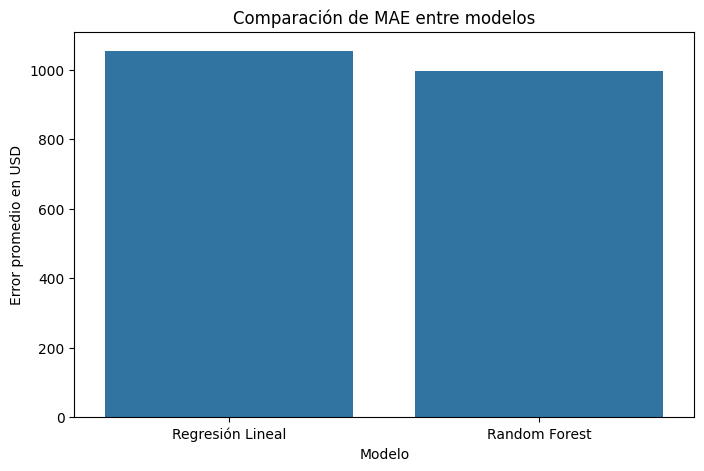

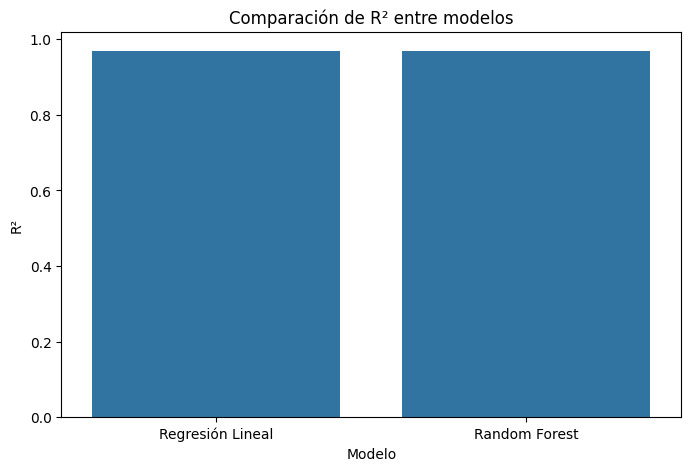

Resumen comparativo de modelos:
- Mejor MAE: Random Forest
- Mejor RMSE: Random Forest
- Mejor R²: Random Forest

Conclusión de la comparación:
Según las métricas, el modelo con mejor rendimiento general fue Random Forest.
Para elegir el mejor modelo, priorizamos menor MAE/RMSE y mayor R². Además, consideramos que el modelo sea defendible y entendible para explicar en clases.

| Métrica | ¿Qué significa? | ¿Cómo se interpreta? |
|==================================================|
| MAE | Error Absoluto Medio | Indica cuánto se equivoca el modelo en promedio, expresado en dólares estadounidenses (USD). Mientras menor sea, mejor. |
| RMSE | Raíz del Error Cuadrático Medio | Mide el error del modelo, pero penaliza más las predicciones muy alejadas del valor real. Mientras menor sea, mejor. |
| R² | Coeficiente de Determinación | Indica qué proporción del precio logra explicar el modelo. Mientras más cercano a 1, mejor. |



In [19]:
resultados = pd.concat([resultados_lineal, resultados_rf], ignore_index=True)

display(resultados)

plt.figure(figsize=(8, 5))
sns.barplot(data=resultados, x='Modelo', y='MAE (USD)')
plt.title('Comparación de MAE entre modelos')
plt.ylabel('Error promedio en USD')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=resultados, x='Modelo', y='R2')
plt.title('Comparación de R² entre modelos')
plt.ylabel('R²')
plt.show()


mejor_mae = resultados.loc[resultados['MAE (USD)'].idxmin(), 'Modelo']
mejor_rmse = resultados.loc[resultados['RMSE (USD)'].idxmin(), 'Modelo']
mejor_r2 = resultados.loc[resultados['R2'].idxmax(), 'Modelo']

print("Resumen comparativo de modelos:")
print(f"- Mejor MAE: {mejor_mae}")
print(f"- Mejor RMSE: {mejor_rmse}")
print(f"- Mejor R²: {mejor_r2}")

print("\nConclusión de la comparación:")
if mejor_mae == mejor_rmse == mejor_r2:
    print(f"Según las métricas, el modelo con mejor rendimiento general fue {mejor_r2}.")
else:
    print("Las métricas no apuntan todas exactamente al mismo modelo, por lo que la comparación se interpreta con cuidado.")

print("Para elegir el mejor modelo, priorizamos menor MAE/RMSE y mayor R². Además, consideramos que el modelo sea defendible y entendible para explicar en clases.")

print("""
| Métrica | ¿Qué significa? | ¿Cómo se interpreta? |
|==================================================|
| MAE | Error Absoluto Medio | Indica cuánto se equivoca el modelo en promedio, expresado en dólares estadounidenses (USD). Mientras menor sea, mejor. |
| RMSE | Raíz del Error Cuadrático Medio | Mide el error del modelo, pero penaliza más las predicciones muy alejadas del valor real. Mientras menor sea, mejor. |
| R² | Coeficiente de Determinación | Indica qué proporción del precio logra explicar el modelo. Mientras más cercano a 1, mejor. |
""")

## 22. Gráfico de valores reales vs valores predichos

Este gráfico nos permite comparar visualmente los precios reales con los precios predichos.

Si los puntos se acercan a la línea diagonal, significa que el modelo predice valores cercanos a los reales.

Graficaremos Random Forest porque esperamos que tenga mejor rendimiento en este problema.

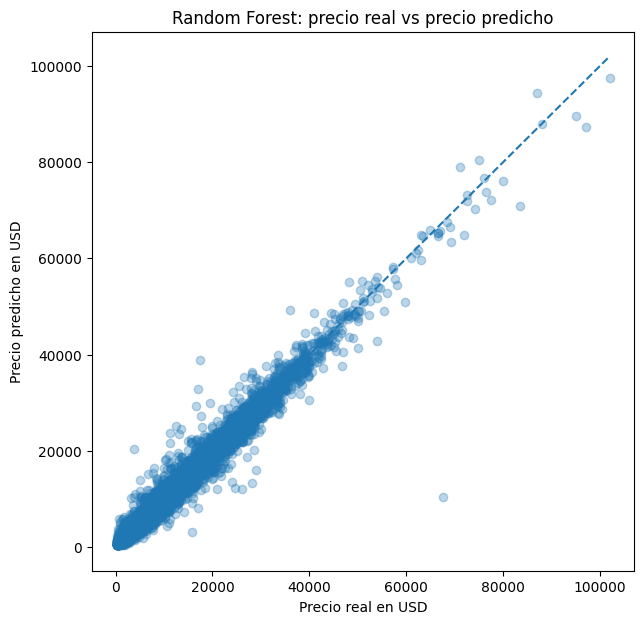

Resumen del gráfico real vs predicho:
Este gráfico compara el precio real del vehículo con el precio que predijo Random Forest.
Si los puntos se acercan a la línea diagonal, significa que las predicciones son cercanas a los valores reales.
Si hay puntos muy alejados de la línea, esos casos representan errores grandes del modelo.

Interpretación del resultado:
El gráfico nos ayuda a ver visualmente si el modelo está siguiendo la tendencia general de los precios, no solo a mirar métricas numéricas.


In [20]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel('Precio real en USD')
plt.ylabel('Precio predicho en USD')
plt.title('Random Forest: precio real vs precio predicho')
plt.show()

print("Resumen del gráfico real vs predicho:")
print("Este gráfico compara el precio real del vehículo con el precio que predijo Random Forest.")
print("Si los puntos se acercan a la línea diagonal, significa que las predicciones son cercanas a los valores reales.")
print("Si hay puntos muy alejados de la línea, esos casos representan errores grandes del modelo.")

print("\nInterpretación del resultado:")
print("El gráfico nos ayuda a ver visualmente si el modelo está siguiendo la tendencia general de los precios, no solo a mirar métricas numéricas.")

## 23. Ejemplo de predicciones

En esta tabla mostraremos algunos precios reales y precios predichos.

Esto nos ayuda a interpretar el error de manera más concreta.  
No basta con mirar métricas; también es útil ver ejemplos reales de cuánto se equivoca el modelo.

In [21]:
comparacion_predicciones = pd.DataFrame({
    'Real USD': y_test.values,
    'Lineal USD': pred_lineal,
    'Random Forest USD': pred_rf
})

comparacion_predicciones['Error Lineal'] = abs(
    comparacion_predicciones['Real USD'] -
    comparacion_predicciones['Lineal USD']
)

comparacion_predicciones['Error RF'] = abs(
    comparacion_predicciones['Real USD'] -
    comparacion_predicciones['Random Forest USD']
)

# Tomamos solo los primeros 10 ejemplos para que sea fácil de mostrar en la presentación
ejemplos_prediccion = comparacion_predicciones.head(10).copy()

display(
    ejemplos_prediccion.style
    .format({
        'Real USD': '${:,.0f}',
        'Lineal USD': '${:,.0f}',
        'Random Forest USD': '${:,.0f}',
        'Error Lineal': '${:,.0f}',
        'Error RF': '${:,.0f}'
    })
    .set_caption("Ejemplos de predicción: precio real vs modelos")
)

prom_error_lineal = ejemplos_prediccion['Error Lineal'].mean()
prom_error_rf = ejemplos_prediccion['Error RF'].mean()

print("\nResumen de estos 10 ejemplos:")
print(f"- Error promedio Regresión Lineal: ${prom_error_lineal:,.0f} USD")
print(f"- Error promedio Random Forest: ${prom_error_rf:,.0f} USD")

if prom_error_rf < prom_error_lineal:
    print("- En esta muestra, Random Forest se acercó más a los precios reales.")
elif prom_error_rf > prom_error_lineal:
    print("- En esta muestra, Regresión Lineal se acercó más a los precios reales.")
else:
    print("- En esta muestra, ambos modelos tuvieron un error similar.")

print("\nNota: estos 10 casos son solo un ejemplo visual. La comparación final se basa en las métricas generales del conjunto de prueba.")

,Real USD,Lineal USD,Random Forest USD,Error Lineal,Error RF
0,"$11,400","$10,584","$11,564",$816,$164
1,"$27,000","$26,763","$26,686",$237,$314
2,"$12,900","$11,064","$12,512","$1,836",$388
3,"$3,100","$4,384","$4,079","$1,284",$979
4,"$6,000","$10,941","$9,802","$4,941","$3,802"
5,"$12,400","$12,286","$12,199",$114,$201
6,"$12,600","$12,864","$12,882",$264,$282
7,"$2,900","$1,799","$2,587","$1,101",$313
8,"$17,800","$18,231","$18,097",$431,$297
9,"$13,500","$13,262","$13,238",$238,$262



Resumen de estos 10 ejemplos:
- Error promedio Regresión Lineal: $1,126 USD
- Error promedio Random Forest: $700 USD
- En esta muestra, Random Forest se acercó más a los precios reales.

Nota: estos 10 casos son solo un ejemplo visual. La comparación final se basa en las métricas generales del conjunto de prueba.


## 24. Interpretación de resultados

En esta parte interpretamos los resultados obtenidos al ejecutar el notebook.

La lectura principal será la siguiente:

- Si Random Forest tiene menor MAE y RMSE, significa que se equivoca menos en promedio.
- Si Random Forest tiene mayor R², significa que explica mejor el comportamiento del precio.
- Si la Regresión Lineal Múltiple tiene resultados aceptables, sirve como modelo base, pero puede ser más limitada.
- Si ambos modelos tienen errores altos, puede deberse a que faltan variables importantes o a que el precio depende de factores difíciles de capturar.

La conclusión se debe basar en las métricas reales que entregue el notebook al ejecutarlo. Si Random Forest obtiene menor error y mayor R², defendemos que predice de forma más eficaz porque captura relaciones más complejas entre las características del vehículo y el precio.


## 25. Experiencia práctica del desarrollo

Durante el desarrollo del trabajo, nosotros identificamos varios puntos importantes:

1. **Existían valores nulos:**  
   Algunas columnas tenían datos faltantes, por lo que eliminamos registros incompletos en las variables usadas.

2. **Había variables categóricas:**  
   Columnas como `make`, `body` y `transmission` estaban en texto, por lo que aplicamos One-Hot Encoder.

3. **El dataset era grande:**  
   Para evitar que el notebook se demorara demasiado durante la presentación, trabajamos con una muestra aleatoria de datos.

4. **La variable `mmr` estaba muy relacionada con el precio:**  
   Esto ayuda al modelo, pero también lo explicamos porque representa una referencia de mercado cercana al precio de venta.

5. **No usamos regresión lineal simple:**  
   La descartamos porque el precio no depende de una sola variable. Por eso usamos Regresión Lineal Múltiple.

6. **Los modelos tienen comportamientos distintos:**  
   La Regresión Lineal Múltiple es más simple e interpretable, mientras que Random Forest puede capturar relaciones más complejas.